# Movie Poster Genre Classification with Deep Learning

In [256]:
import csv
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import torch
from pprint import pprint
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    resnet50, ResNet50_Weights,
)

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


CONFIG = {
    "DATASET_DIR": "tmdb_dataset",
    "METADATA_CSV": "metadata.csv",
    "LABEL_COL": "target_genre_slug",
    "PATH_COL": "local_path",
    "SEED": 742617000027,
    "TRAIN_FRACTION": 0.80,
    "VAL_FRACTION": 0.10,
    "TEST_FRACTION": 0.10,
    "BACKBONE": "resnet50",
    "IMAGE_H": 432,
    "IMAGE_W": 288,
    "HEAD_HIDDEN": 256,
    "HEAD_DROPOUT": 0.35,
    "EPOCHS": 35,
    "BATCH_SIZE": 32,
    "NUM_WORKERS": 0,
    "WEIGHT_DECAY": 1e-4,
    "LABEL_SMOOTHING": 0.05,
    "USE_AMP": True,
    "GRAD_CLIP_NORM": 1.0,
    "LR_BACKBONE": 5e-5,
    "LR_HEAD": 5e-4,
    "SCHEDULER": "cosine",
    "USE_RANDAUGMENT": True,
    "RANDAUG_NUM_OPS": 2,
    "RANDAUG_MAGNITUDE": 7,
    "AUG_RE_SCALE": (0.85, 1.00),
    "AUG_COLORJITTER": (0.10, 0.10, 0.06, 0.02),
    "AUG_RANDOM_ERASE_P": 0.10,
    "MIXUP_ALPHA": 0.2,
    "MIXUP_PROB": 0.5,
    "PATIENCE": 10,
    "OUTPUT_DIR": "runs_poster_genre",
    "SAVE_BEST_MODEL": "best_model_noema.pt",
    "SAVE_SPLITS_CSV": "splits_noema.csv",
}

## Постановка задачи

Данный проект посвящён задаче многоклассовой классификации жанра фильма по изображению его постера. Визуальная идентификация жанра - задача, с которой человек справляется интуитивно: цветовая палитра, композиция, типографика и образы персонажей формируют устойчивые стереотипы жанрового восприятия. Цель работы - проверить, насколько эти визуальные паттерны поддаются формализации и могут быть извлечены свёрточной нейронной сетью.

Проект охватывает **полный цикл разработки ML-решения**: сбор и предобработка данных, построение и обучение модели, оценка качества и интерпретация результатов.

![](https://static.boredpanda.com/blog/wp-content/uuuploads/movie-poster-cliches/movie-poster-cliches-3.jpg)

Датасет: коллекция постеров фильмов с жанровой разметкой - доступен по [ссылке](https://clck.ru/3RBeCS).

## Архитектура и реализация

##### В основе решения - свёрточная нейронная сеть на базе предобученной ResNet50 (ImageNet) с дообученной классификационной головой, адаптированной под задачу распознавания жанра по постеру.

##### Рассмотрим ключевые компоненты реализации:

- **`set_seed`** - фиксирует все генераторы случайных чисел для воспроизводимости экспериментов
- **`read_metadata`** - загружает `metadata.csv`, валидирует структуру и формирует список пар (путь к изображению, жанр)
- **`build_label_map`** - строит детерминированное отображение жанр → числовой индекс
- **`stratified_split`** - стратифицированное разбиение на train / val / test с сохранением распределения классов

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


@dataclass
class Sample:
    path: Path
    label: int


def read_metadata(dataset_dir: Path, metadata_csv: Path, path_col: str, label_col: str) -> List[Tuple[Path, str]]:
    rows: List[Tuple[Path, str]] = []
    with metadata_csv.open("r", encoding="utf-8", newline="") as f:
        r = csv.DictReader(f)
        fields = r.fieldnames or []
        if path_col not in fields or label_col not in fields:
            raise ValueError(f"metadata.csv columns: {fields}. Need {path_col=} and {label_col=}.")
        for row in r:
            rel = (row.get(path_col) or "").strip()
            lab = (row.get(label_col) or "").strip()
            if not rel or not lab:
                continue
            p = (dataset_dir / rel).resolve()
            rows.append((p, lab))
    return rows


def build_label_map(labels: List[str]) -> Dict[str, int]:
    uniq = sorted(set(labels))
    return {name: i for i, name in enumerate(uniq)}


def stratified_split(
    paths_labels: List[Tuple[Path, str]],
    label_to_idx: Dict[str, int],
    train_frac: float,
    val_frac: float,
    test_frac: float,
    seed: int,
) -> Tuple[List[Sample], List[Sample], List[Sample]]:
    if abs((train_frac + val_frac + test_frac) - 1.0) > 1e-6:
        raise ValueError("Split fractions must sum to 1.0")

    rng = random.Random(seed)
    buckets: Dict[int, List[Path]] = {}
    for p, lab in paths_labels:
        y = label_to_idx[lab]
        buckets.setdefault(y, []).append(p)

    train: List[Sample] = []
    val: List[Sample] = []
    test: List[Sample] = []

    for y, plist in buckets.items():
        rng.shuffle(plist)
        n = len(plist)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_train = min(n_train, n)
        n_val = min(n_val, n - n_train)
        n_test = n - n_train - n_val

        train += [Sample(p, y) for p in plist[:n_train]]
        val += [Sample(p, y) for p in plist[n_train : n_train + n_val]]
        test += [Sample(p, y) for p in plist[n_train + n_val : n_train + n_val + n_test]]

    rng.shuffle(train)
    rng.shuffle(val)
    rng.shuffle(test)
    return train, val, test

- **`PosterDataset`** - кастомный `Dataset`: загружает изображение по индексу, конвертирует в RGB, применяет трансформации; при ошибке чтения подставляет тензор-заглушку для устойчивости пайплайна
- **`mixup_batch`** - реализует аугментацию **MixUp**: выпуклая комбинация пар изображений и их меток, улучшает обобщающую способность модели

In [ ]:
class PosterDataset(Dataset):
    def __init__(self, samples: List[Sample], transform):
        self.samples = samples
        self.transform = transform

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        s = self.samples[idx]
        try:
            img = Image.open(s.path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (int(CONFIG["IMAGE_W"]), int(CONFIG["IMAGE_H"])), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        y = torch.tensor(s.label, dtype=torch.long)
        return img, y


def mixup_batch(x: torch.Tensor, y: torch.Tensor, alpha: float):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1.0 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return x_mix, y_a, y_b, lam

Модуль оценки качества: вычисляет **macro-F1**, кросс-энтропийный loss и accuracy по матрице ошибок. Macro-усреднение не зависит от дисбаланса классов и даёт объективную картину качества классификации по каждому жанру.

In [ ]:
@torch.no_grad()
def macro_f1_from_cm(cm: torch.Tensor) -> float:
    cm = cm.to(torch.float32)
    tp = cm.diag()
    fp = cm.sum(dim=0) - tp
    fn = cm.sum(dim=1) - tp
    precision = tp / (tp + fp).clamp_min(1.0)
    recall = tp / (tp + fn).clamp_min(1.0)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)

    return f1.mean().item()


@torch.no_grad()
def evaluate_with_f1(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    criterion: nn.Module,
    num_classes: int,
) -> Tuple[float, float, float, torch.Tensor]:
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        preds = logits.argmax(1)
        total_loss += loss.item() * y.size(0)
        total_correct += (preds == y).sum().item()
        total += y.size(0)
        y_cpu = y.view(-1).to("cpu")
        p_cpu = preds.view(-1).to("cpu")
        idx = y_cpu * num_classes + p_cpu
        cm += torch.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

    avg_loss = total_loss / max(1, total)
    acc = total_correct / max(1, total)
    macro_f1 = macro_f1_from_cm(cm)
    return avg_loss, acc, macro_f1, cm

Функция построения модели: **ResNet50** в качестве backbone (с возможностью замены через аргумент), стандартный `fc`-слой заменён на кастомную голову **Linear → BatchNorm → ReLU → Dropout → Linear(num_classes)**.

Оптимизатор - **AdamW** с раздельными learning rate для backbone и головы (дифференцированный fine-tuning). Планировщик - **CosineAnnealingLR** для плавного снижения lr.

In [ ]:
def build_model(num_classes: int):
    if CONFIG["BACKBONE"] == "resnet18":
        weights = ResNet18_Weights.IMAGENET1K_V1
        model = resnet18(weights=weights)
    elif CONFIG["BACKBONE"] == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)
    else:
        raise ValueError("BACKBONE must be 'resnet18' or 'resnet50'")

    in_features = model.fc.in_features
    hidden = int(CONFIG["HEAD_HIDDEN"])
    drop = float(CONFIG["HEAD_DROPOUT"])
    model.fc = nn.Sequential(
        nn.Linear(in_features, hidden),
        nn.ReLU(inplace=True),
        nn.Dropout(p=drop),
        nn.Linear(hidden, num_classes),
    )
    return model, weights


def make_optimizer(model: nn.Module) -> torch.optim.Optimizer:
    wd = float(CONFIG["WEIGHT_DECAY"])
    head_params = list(model.fc.parameters())
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
    return torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": float(CONFIG["LR_BACKBONE"])},
            {"params": head_params, "lr": float(CONFIG["LR_HEAD"])},
        ],
        weight_decay=wd,
    )


def make_scheduler(optimizer: torch.optim.Optimizer, total_epochs: int):
    if CONFIG["SCHEDULER"] == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)
    raise ValueError("Unknown scheduler")

In [ ]:
set_seed(int(CONFIG["SEED"]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
dataset_dir = Path(CONFIG["DATASET_DIR"]).resolve()
metadata_csv = (dataset_dir / CONFIG["METADATA_CSV"]).resolve()

out_dir = Path(CONFIG["OUTPUT_DIR"]).resolve()
out_dir.mkdir(parents=True, exist_ok=True)

rows = read_metadata(dataset_dir, metadata_csv, CONFIG["PATH_COL"], CONFIG["LABEL_COL"])
rows = [(p, lab) for (p, lab) in rows if p.exists() and p.stat().st_size > 0]

if not rows:
    raise RuntimeError("No valid images found. Check DATASET_DIR / metadata.csv")

labels = [lab for _, lab in rows]
label_to_idx = build_label_map(labels)
idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes = len(label_to_idx)

train_s, val_s, test_s = stratified_split(
    rows,
    label_to_idx,
    float(CONFIG["TRAIN_FRACTION"]),
    float(CONFIG["VAL_FRACTION"]),
    float(CONFIG["TEST_FRACTION"]),
    int(CONFIG["SEED"]),
)

splits_csv = out_dir / CONFIG["SAVE_SPLITS_CSV"]
with splits_csv.open("w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["split", "path", "label_idx", "label_name"])
    for split_name, samples in [("train", train_s), ("val", val_s), ("test", test_s)]:
        for s in samples:
            w.writerow([split_name, str(s.path), s.label, idx_to_label[s.label]])

print(f"Classes: {num_classes}")
print(f"Train/Val/Test: {len(train_s)}/{len(val_s)}/{len(test_s)}")
sorted(label_to_idx.keys())[:20], ("...",) if num_classes > 20 else ()

Classes: 7
Train/Val/Test: 11199/1400/1400


(['animation',
  'comedy',
  'horror',
  'romance',
  'science-fiction',
  'war',
  'western'],
 ())

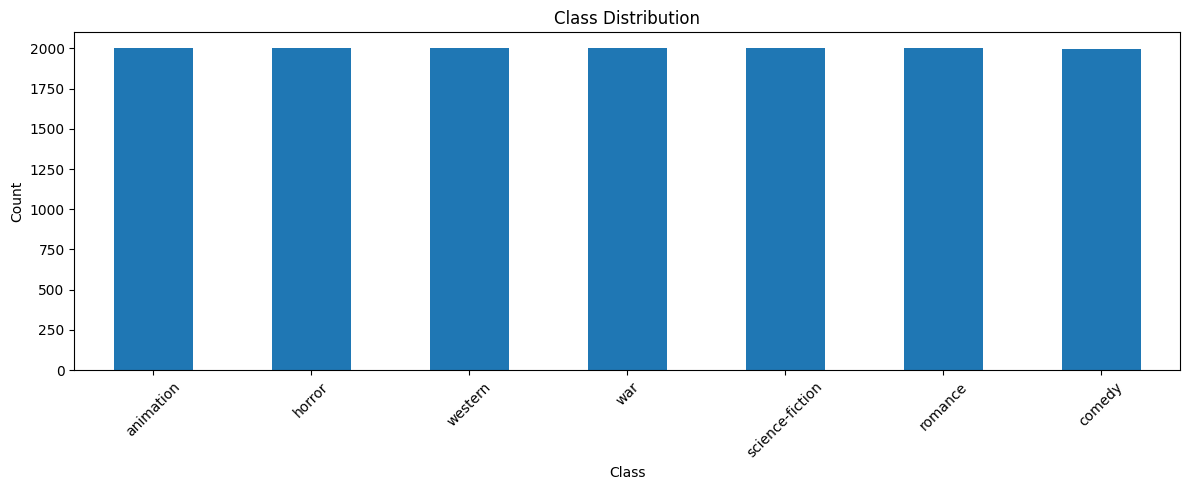

In [ ]:
df_meta = pd.DataFrame(rows, columns=["path", "class"])

plt.figure(figsize=(12, 5))
df_meta["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

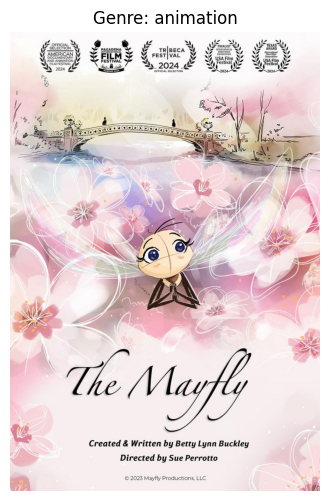

In [ ]:
rng = random.SystemRandom()
img_path, lab_name = rng.choice(rows)

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Genre: {lab_name}", fontsize=12)
plt.show()

Настройка пайплайна данных: ImageNet-нормализация, тренировочные аугментации (`RandomResizedCrop`, `HorizontalFlip`, `ColorJitter`, `RandAugment`, `RandomErasing`), eval-преобразования (`Resize` + `CenterCrop` + `Normalize`), `DataLoader`'ы для train / val / test с настройкой батча и параллельной загрузки.

In [ ]:
model, weights = build_model(num_classes)
model = model.to(device)

H = int(CONFIG["IMAGE_H"])
W = int(CONFIG["IMAGE_W"])

mean, std = weights.transforms().mean, weights.transforms().std

poster_ratio = W / H
ratio_range = (poster_ratio * 0.90, poster_ratio * 1.10)

aug_list = [
    transforms.RandomResizedCrop(
        size=(H, W),
        scale=tuple(CONFIG["AUG_RE_SCALE"]),
        ratio=ratio_range
    ),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ColorJitter(*CONFIG["AUG_COLORJITTER"]),
]

if bool(CONFIG["USE_RANDAUGMENT"]):
    aug_list.append(
        transforms.RandAugment(
            num_ops=int(CONFIG["RANDAUG_NUM_OPS"]),
            magnitude=int(CONFIG["RANDAUG_MAGNITUDE"])
        )
    )

train_tfms = transforms.Compose(
    aug_list + [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
        transforms.RandomErasing(
            p=float(CONFIG["AUG_RANDOM_ERASE_P"]),
            scale=(0.02, 0.12),
            ratio=(0.3, 3.3),
            value=0
        ),
    ]
)

eval_tfms = transforms.Compose([
    transforms.Resize((int(H * 1.15), int(W * 1.15))),
    transforms.CenterCrop((H, W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_loader = DataLoader(
    PosterDataset(train_s, train_tfms),
    batch_size=int(CONFIG["BATCH_SIZE"]),
    shuffle=True,
    num_workers=int(CONFIG["NUM_WORKERS"]),
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

val_loader = DataLoader(
    PosterDataset(val_s, eval_tfms),
    batch_size=int(CONFIG["BATCH_SIZE"]),
    shuffle=False,
    num_workers=int(CONFIG["NUM_WORKERS"]),
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    PosterDataset(test_s, eval_tfms),
    batch_size=int(CONFIG["BATCH_SIZE"]),
    shuffle=False,
    num_workers=int(CONFIG["NUM_WORKERS"]),
    pin_memory=(device.type == "cuda"),
)

Настройка обучения: вычисление весов классов для балансировки выборки, **CrossEntropyLoss** с `label_smoothing=0.1` в качестве регуляризации, оптимизатор **AdamW** с дифференцированным lr, планировщик **CosineAnnealingLR**, ранняя остановка по `val macro-F1`, **MixUp**-аугментация и **gradient clipping** для стабильности градиентного спуска.

In [ ]:
counts = torch.bincount(
    torch.tensor([s.label for s in train_s], dtype=torch.long),
    minlength=num_classes
).float()

class_w = (counts.sum() / counts).clamp(max=10.0)
class_w = class_w / class_w.mean()
class_w = class_w.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_w,
    label_smoothing=float(CONFIG["LABEL_SMOOTHING"])
)

optimizer = make_optimizer(model)
scheduler = make_scheduler(optimizer, total_epochs=int(CONFIG["EPOCHS"]))

scaler = GradScaler(
    device.type,
    enabled=bool(CONFIG["USE_AMP"] and device.type == "cuda")
)

best_path = out_dir / CONFIG["SAVE_BEST_MODEL"]
best_val_acc = -1.0
patience = int(CONFIG["PATIENCE"])
no_improve = 0

mix_alpha = float(CONFIG["MIXUP_ALPHA"])
mix_prob = float(CONFIG["MIXUP_PROB"])
clip = float(CONFIG["GRAD_CLIP_NORM"])

In [ ]:
print(model)

print("\n--- FC head ---")
print(model.fc)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
print("=== CONFIG ===")
pprint(CONFIG)

print("\n=== RUN SUMMARY ===")
summary = {
    "dataset_dir": CONFIG["DATASET_DIR"],
    "metadata_csv": CONFIG["METADATA_CSV"],
    "label_col": CONFIG["LABEL_COL"],
    "path_col": CONFIG["PATH_COL"],
    "seed": CONFIG["SEED"],
    "splits": {
        "train_frac": CONFIG["TRAIN_FRACTION"],
        "val_frac": CONFIG["VAL_FRACTION"],
        "test_frac": CONFIG["TEST_FRACTION"],
        "train_n": len(train_s),
        "val_n": len(val_s),
        "test_n": len(test_s),
        "num_classes": num_classes,
        "classes": [idx_to_label[i] for i in range(num_classes)],
    },
    "model": {
        "backbone": CONFIG["BACKBONE"],
        "image_hw": (CONFIG["IMAGE_H"], CONFIG["IMAGE_W"]),
        "head_hidden": CONFIG["HEAD_HIDDEN"],
        "head_dropout": CONFIG["HEAD_DROPOUT"],
    },
    "training": {
        "epochs": CONFIG["EPOCHS"],
        "batch_size": CONFIG["BATCH_SIZE"],
        "num_workers": CONFIG["NUM_WORKERS"],
        "use_amp": CONFIG["USE_AMP"],
        "grad_clip_norm": CONFIG["GRAD_CLIP_NORM"],
        "weight_decay": CONFIG["WEIGHT_DECAY"],
        "label_smoothing": CONFIG["LABEL_SMOOTHING"],
        "lr_backbone": CONFIG["LR_BACKBONE"],
        "lr_head": CONFIG["LR_HEAD"],
        "scheduler": CONFIG["SCHEDULER"],
        "patience": CONFIG["PATIENCE"],
        "mixup": {"alpha": CONFIG["MIXUP_ALPHA"], "prob": CONFIG["MIXUP_PROB"]},
    },
    "augmentation": {
        "use_randaugment": CONFIG["USE_RANDAUGMENT"],
        "randaug_num_ops": CONFIG["RANDAUG_NUM_OPS"],
        "randaug_magnitude": CONFIG["RANDAUG_MAGNITUDE"],
        "random_resized_crop_scale": CONFIG["AUG_RE_SCALE"],
        "colorjitter": CONFIG["AUG_COLORJITTER"],
        "random_erasing_p": CONFIG["AUG_RANDOM_ERASE_P"],
    },
    "output": {
        "output_dir": CONFIG["OUTPUT_DIR"],
        "save_best_model": CONFIG["SAVE_BEST_MODEL"],
        "save_splits_csv": CONFIG["SAVE_SPLITS_CSV"],
    }
}
pprint(summary)

=== CONFIG ===
{'AUG_COLORJITTER': (0.1, 0.1, 0.06, 0.02),
 'AUG_RANDOM_ERASE_P': 0.1,
 'AUG_RE_SCALE': (0.85, 1.0),
 'BACKBONE': 'resnet50',
 'BATCH_SIZE': 32,
 'DATASET_DIR': 'tmdb_dataset',
 'EPOCHS': 35,
 'GRAD_CLIP_NORM': 1.0,
 'HEAD_DROPOUT': 0.35,
 'HEAD_HIDDEN': 256,
 'IMAGE_H': 432,
 'IMAGE_W': 288,
 'LABEL_COL': 'target_genre_slug',
 'LABEL_SMOOTHING': 0.05,
 'LR_BACKBONE': 5e-05,
 'LR_HEAD': 0.0005,
 'METADATA_CSV': 'metadata.csv',
 'MIXUP_ALPHA': 0.2,
 'MIXUP_PROB': 0.5,
 'NUM_WORKERS': 0,
 'OUTPUT_DIR': 'runs_poster_genre',
 'PATH_COL': 'local_path',
 'PATIENCE': 10,
 'RANDAUG_MAGNITUDE': 7,
 'RANDAUG_NUM_OPS': 2,
 'SAVE_BEST_MODEL': 'best_model_noema.pt',
 'SAVE_SPLITS_CSV': 'splits_noema.csv',
 'SCHEDULER': 'cosine',
 'SEED': 742617000027,
 'TEST_FRACTION': 0.1,
 'TRAIN_FRACTION': 0.8,
 'USE_AMP': True,
 'USE_RANDAUGMENT': True,
 'VAL_FRACTION': 0.1,
 'WEIGHT_DECAY': 0.0001}

=== RUN SUMMARY ===
{'augmentation': {'colorjitter': (0.1, 0.1, 0.06, 0.02),
                  '

In [ ]:
for epoch in range(1, int(CONFIG["EPOCHS"]) + 1):
    model.train()
    running_loss, running_total = 0.0, 0
    acc_correct, acc_total = 0, 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        use_mix = (mix_alpha > 0) and (random.random() < mix_prob)
        if use_mix:
            x_in, y_a, y_b, lam = mixup_batch(x, y, mix_alpha)
        else:
            x_in, y_a, y_b, lam = x, y, y, 1.0

        with autocast(device_type=device.type, dtype=torch.float16, enabled=scaler.is_enabled()):
            logits = model(x_in)
            if use_mix:
                loss = lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)
            else:
                loss = criterion(logits, y)

        scaler.scale(loss).backward()

        if clip and clip > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * y.size(0)
        running_total += y.size(0)

        if not use_mix:
            acc_correct += (logits.argmax(1) == y).sum().item()
            acc_total += y.size(0)

    scheduler.step()

    train_loss = running_loss / max(1, running_total)
    train_acc = acc_correct / max(1, acc_total) if acc_total > 0 else float("nan")

    val_loss, val_acc, val_f1, _ = evaluate_with_f1(model, val_loader, device, criterion, num_classes)

    print(
        f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
        f"train: loss={train_loss:.4f} acc={train_acc*100:.2f}% | "
        f"val: loss={val_loss:.4f} acc={val_acc*100:.2f}% macroF1={val_f1:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        torch.save(
            {"model_state": model.state_dict(), "label_to_idx": label_to_idx, "config": CONFIG},
            best_path,
        )
        print(f"New best val acc: {best_val_acc*100:.2f}% (saved to {best_path})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping: no val improvement for {patience} epochs.")
            break

Epoch 01/35 | train: loss=1.2118 acc=64.53% | val: loss=0.9415 acc=70.86% macroF1=0.7106
New best val acc: 70.86% (saved to C:\Users\Computer\VScode\Labels\runs_poster_genre\best_model_noema.pt)
Epoch 02/35 | train: loss=0.9741 acc=75.25% | val: loss=0.8718 acc=75.07% macroF1=0.7489
New best val acc: 75.07% (saved to C:\Users\Computer\VScode\Labels\runs_poster_genre\best_model_noema.pt)
Epoch 03/35 | train: loss=0.8376 acc=81.18% | val: loss=0.8817 acc=75.07% macroF1=0.7479
Epoch 04/35 | train: loss=0.7519 acc=84.71% | val: loss=0.8787 acc=74.21% macroF1=0.7445
Epoch 05/35 | train: loss=0.6923 acc=89.44% | val: loss=0.8946 acc=75.29% macroF1=0.7512
New best val acc: 75.29% (saved to C:\Users\Computer\VScode\Labels\runs_poster_genre\best_model_noema.pt)
Epoch 06/35 | train: loss=0.6282 acc=91.53% | val: loss=0.9372 acc=75.86% macroF1=0.7558
New best val acc: 75.86% (saved to C:\Users\Computer\VScode\Labels\runs_poster_genre\best_model_noema.pt)
Epoch 07/35 | train: loss=0.5785 acc=94.26

In [ ]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state"], strict=True)

test_loss, test_acc, test_f1, cm = evaluate_with_f1(model, test_loader, device, criterion, num_classes)

print(f"TEST: loss={test_loss:.4f} acc={test_acc*100:.2f}% macroF1={test_f1:.4f}")

TEST: loss=0.9746 acc=75.36% macroF1=0.7498


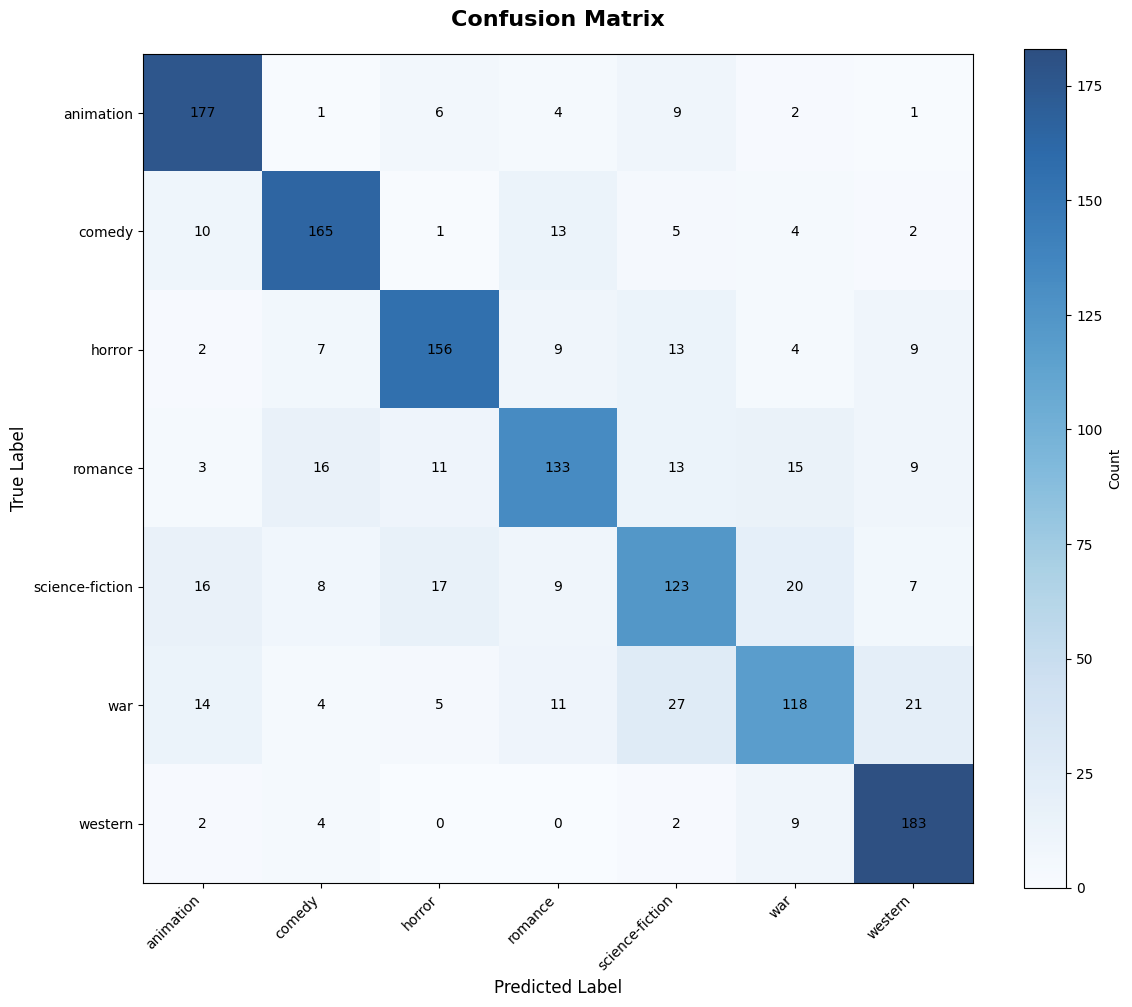

In [ ]:
cm_np = cm.cpu().numpy()
class_names = [idx_to_label[i] for i in range(num_classes)]

plt.figure(figsize=(12, 10))
plt.imshow(cm_np, interpolation="nearest", cmap="Blues", alpha=0.85)
plt.title("Confusion Matrix", fontsize=16, fontweight="bold", pad=20)
plt.colorbar(label="Count")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names, rotation=0)

for i in range(num_classes):
    for j in range(num_classes):
        v = int(cm_np[i, j])
        plt.text(
            j, i, f"{v}",
            ha="center", va="center",
            fontsize=10,
            color="black",
        )

plt.tight_layout()
plt.show()

In [ ]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(y.numpy().tolist())

class_names = [idx_to_label[i] for i in range(num_classes)]

print(
    classification_report(
        all_labels,
        all_preds,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=3,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

      animation      0.790     0.885     0.835       200
         comedy      0.805     0.825     0.815       200
         horror      0.796     0.780     0.788       200
        romance      0.743     0.665     0.702       200
science-fiction      0.641     0.615     0.628       200
            war      0.686     0.590     0.634       200
        western      0.789     0.915     0.847       200

       accuracy                          0.754      1400
      macro avg      0.750     0.754     0.750      1400
   weighted avg      0.750     0.754     0.750      1400



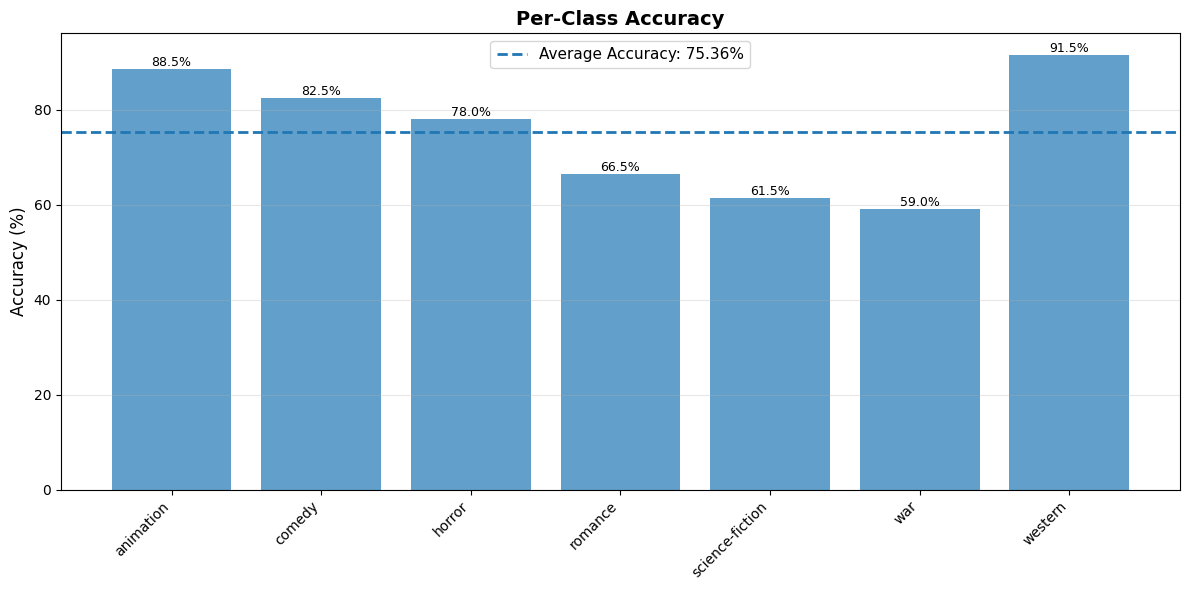

In [ ]:
cm_np = cm.cpu().numpy()
per_class_acc = (np.diag(cm_np) / np.maximum(cm_np.sum(axis=1), 1)) * 100

class_names = [idx_to_label[i] for i in range(num_classes)]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_names)), per_class_acc, alpha=0.7)
plt.axhline(
    y=test_acc * 100,
    linestyle="--",
    label=f"Average Accuracy: {test_acc*100:.2f}%",
    linewidth=2
)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Per-Class Accuracy", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, axis="y", alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{per_class_acc[i]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Результаты и анализ

Модель достигла **75% accuracy на тестовой выборке** при сбалансированном качестве по всем классам - результат не вытягивается одним доминирующим жанром. Лучшее значение **macro-F1 = 75.86%** достигнуто на 6-й эпохе, после чего зафиксировано переобучение и обучение остановлено досрочно.

**Точность по жанрам:**
| Жанр | Accuracy |
|---|---|
| Вестерн | ~91.5% |
| Анимация | ~88.5% |
| Комедия | ~82.5% |
| Хоррор | ~78% |
| Романтика | ~66.5% |
| Sci-Fi | ~61.5% |
| Военные | ~59% |

Анализ матрицы ошибок выявил устойчивые паттерны смешения: военные фильмы чаще всего путаются с sci-fi и вестерном; sci-fi - с хоррором и анимацией. Это объясняется пересечением визуальных мотивов (экшен, оружие, драматическое освещение) между этими жанрами. Романтика и комедия смешиваются из-за схожей визуальной подачи (лица крупным планом, светлая палитра, характерная типографика).

Гипотеза о предсказуемости жанра фильма по постеру **подтверждена**: CNN способна извлекать устойчивые жанровые визуальные паттерны и классифицировать фильмы с приемлемым качеством. Жанры с выраженной визуальной идентичностью (вестерн, анимация, комедия, хоррор) распознаются значительно лучше. Жанры с пересекающейся стилистикой (war, sci-fi, romance) представляют наибольшую сложность - что соответствует интуитивным ожиданиям и отражает реальную неоднозначность жанровой классификации в кино.

![](https://www.pravilamag.ru/upload/img_cache/110/110d4be52ed477cd892f9f0d38ee487a_ce_1367x911x89x0_cropped_510x340.webp)